# TASK 2 - Customer Retention & Churn Analysis
# Dataset : Telco Customer Churn (Kaggle)
# Tool    : Python + Jupyter Notebook

In [30]:
# Import Necessary Libraries 
import pandas as pd               # For manipulating data tables
import numpy as np                # For mathematical operations
import matplotlib.pyplot as plt   # For drawing basic charts
import seaborn as sns             # For drawing beautiful statistical charts
import warnings                   # To hide messy warning messages
warnings.filterwarnings('ignore')

# Display settings 
pd.set_option('display.max_columns', None)  # Ensures Python doesn't hide any columns
print("Libraries imported successfully!")

# Load the Dataset 
df = pd.read_csv("Telco Customer Churn.csv")

print("\n Dataset loaded successfully!")
print(f" Shape of dataset: {df.shape[0]} customers × {df.shape[1]} columns")

# Inspect the Data 
print("\n First 10 Customers:")
display(df.head(10))

print("\n-----------------------------------------")

# Let's check the health of our dataset (data types and missing values)
print("Dataset Health Check:")
df.info()

Libraries imported successfully!

 Dataset loaded successfully!
 Shape of dataset: 7043 customers × 21 columns

 First 10 Customers:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



-----------------------------------------
Dataset Health Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 n

# SECTION 2 - Data Cleaning


In [32]:
# Convert TotalCharges from text to numbers
# 'errors=coerce' forces those blank spaces (" ") to become NaN (Not a Number)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the missing values with 0 (since they are new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop the 'customerID' column
df = df.drop('customerID', axis=1)

# Standardize the 'Churn' column from Yes/No to 1/0 for easier math later
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(" Data cleaning complete!")
print("\n Check missing values now:")
print(df.isnull().sum())

 Data cleaning complete!

 Check missing values now:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# SECTION 4 — Exploratory Data Analysis (Why are they leaving?)

 Overall Baseline Churn Rate: 26.54%



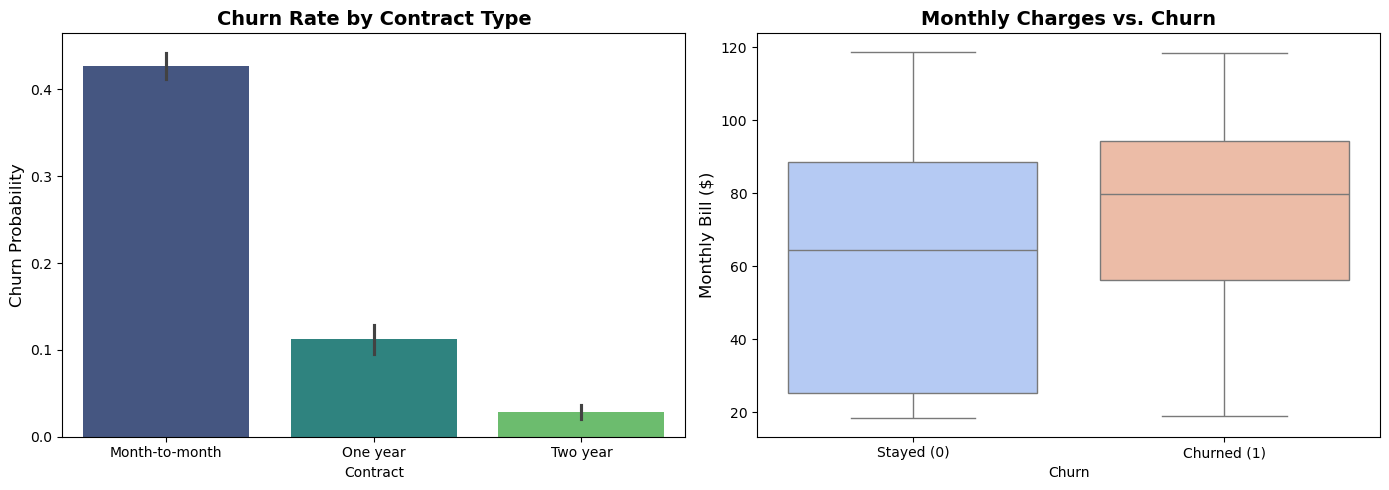

In [34]:
# Calculate the overall baseline Churn Rate
churn_rate = df['Churn'].mean() * 100
print(f" Overall Baseline Churn Rate: {churn_rate:.2f}%\n")

# Build visualizations to find the "Retention Drivers"
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Churn Rate by Contract Type
sns.barplot(data=df, x='Contract', y='Churn', palette='viridis', ax=ax[0])
ax[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Churn Probability', fontsize=12)

# Chart 2: How Monthly Charges affect Churn
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='coolwarm', ax=ax[1])
ax[1].set_title('Monthly Charges vs. Churn', fontsize=14, fontweight='bold')
ax[1].set_xticklabels(['Stayed (0)', 'Churned (1)'])
ax[1].set_ylabel('Monthly Bill ($)', fontsize=12)

plt.tight_layout()
plt.show()

# SECTION 5 — Churn Prediction Model (Random Forest)

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#  Feature Engineering: Select our columns and convert text to numbers
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'PaymentMethod']
# pd.get_dummies turns categories like "Month-to-month" into 1s and 0s for the math
X = pd.get_dummies(df[features], drop_first=True)
y = df['Churn']

#  Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Train a Random Forest Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#  Make Predictions and check accuracy
predictions = model.predict(X_test)
print("Machine Learning Model Results:\n")
print(f"Model Accuracy: {accuracy_score(y_test, predictions)*100:.2f}%\n")

# 5. Extract Feature Importance (What actually drives churn?)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 3 Most Important Factors Driving Churn:")
print(importances.head(3))

Machine Learning Model Results:

Model Accuracy: 78.14%

Top 3 Most Important Factors Driving Churn:
TotalCharges      0.305643
MonthlyCharges    0.293478
tenure            0.208772
dtype: float64


# SECTION 6 — Export Clean Data

In [38]:
# Save our cleaned DataFrame to a new CSV file
df.to_csv('Cleaned_Telco_Churn.csv', index=False)

print("Clean dataset successfully exported as 'Cleaned_Telco_Churn.csv'!")

Clean dataset successfully exported as 'Cleaned_Telco_Churn.csv'!
